In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os, json, shutil
import numpy as np
import matplotlib.pyplot as plt
import itertools
from math import ceil
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

In [9]:
DRIVE_BASE = "/content/drive/MyDrive/chest_xray"
TRAIN_DIR = os.path.join(DRIVE_BASE, "train")
VALID_DIR = os.path.join(DRIVE_BASE, "test")
MODEL_NAME = "chest_pneumonia_model"
OUT_DIR = f"/content/{MODEL_NAME}"

IMAGE_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 8
LEARNING_RATE = 1e-4
NUM_CLASSES = 1
os.makedirs(OUT_DIR, exist_ok=True)

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import preprocess_input as res_preprocess

train_aug = ImageDataGenerator(
    preprocessing_function=res_preprocess,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    shear_range=0.05,
    zoom_range=0.08,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_aug = ImageDataGenerator(preprocessing_function=res_preprocess)

train_gen = train_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

valid_gen = valid_aug.flow_from_directory(
    VALID_DIR,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    color_mode='rgb',
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

index_to_label = {v: k for k, v in train_gen.class_indices.items()}
class_labels = [index_to_label[i] for i in range(len(index_to_label))]
print("Detected class labels (index->label):", index_to_label)

Found 5232 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Detected class labels (index->label): {0: 'NORMAL', 1: 'PNEUMONIA'}


In [11]:
inputs = Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name="input_image")
base = ResNet50(include_top=False, weights="imagenet", input_tensor=inputs)

for layer in base.layers:
    layer.trainable = False

for layer in base.layers[-20:]:
    layer.trainable = True

x = base.output
x = GlobalAveragePooling2D(name="gap")(x)
x = Dropout(0.3)(x)
outputs = Dense(1, activation="sigmoid", name="predictions")(x)

model = Model(inputs=inputs, outputs=outputs, name="ResNet50_chest")
model.compile(optimizer=Adam(LEARNING_RATE), loss="binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])

steps_per_epoch = ceil(train_gen.samples / train_gen.batch_size)
validation_steps = ceil(valid_gen.samples / valid_gen.batch_size)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_data=valid_gen,
    validation_steps=validation_steps,
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 1618s 5s/step - accuracy: 0.8930 - auc: 0.9492 - loss: 0.2207 - val_accuracy: 0.9359 - val_auc: 0.9780 - val_loss: 0.1990
Epoch 2/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 1318s 4s/step - accuracy: 0.9759 - auc: 0.9961 - loss: 0.0649 - val_accuracy: 0.9391 - val_auc: 0.9824 - val_loss: 0.1775
Epoch 3/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 1336s 4s/step - accuracy: 0.9804 - auc: 0.9964 - loss: 0.0596 - val_accuracy: 0.9359 - val_auc: 0.9811 - val_loss: 0.2173
Epoch 4/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 1346s 4s/step - accuracy: 0.9840 - auc: 0.9980 - loss: 0.0461 - val_accuracy: 0.9471 - val_auc: 0.9811 - val_loss: 0.1847
Epoch 5/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 1373s 4s/step - accuracy: 0.9878 - auc: 0.9986 - loss: 0.0360 - val_accuracy: 0.9359 - val_auc: 0.9806 - val_loss: 0.2304
Epoch 6/8
327/327 ━━━━━━━━━━━━━━━━━━━━ 1288s 4s/step - accuracy: 0.9899 - auc: 0.9987 - loss: 0.0284 - val_accuracy: 0.9551 - val_auc: 0.9866 - val_loss: 0.1480
Epoch 7/8
327/327 ━━━━━━━━━━━━━━━━

In [ ]:
def generator_predict_and_labels(model, generator):
    steps = ceil(generator.samples / generator.batch_size)
    preds = model.predict(generator, steps=steps, verbose=1)
    if preds.ndim == 2 and preds.shape[1] == 1:
        y_score = preds.flatten()
    else:
        y_score = preds
    y_true = generator.classes  
    return np.array(y_true), np.array(y_score)

y_true, y_score = generator_predict_and_labels(model, valid_gen)

if y_score.ndim == 1: 
    y_pred = (y_score >= 0.5).astype(int)
else:
    y_pred = np.argmax(y_score, axis=1)

39/39 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step


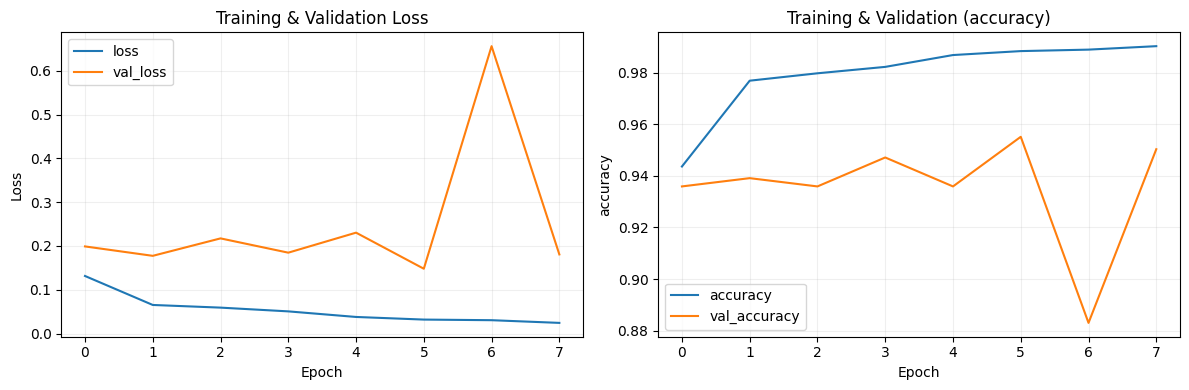

In [ ]:
hist = history.history
loss_key = "loss"
val_loss_key = "val_loss" if "val_loss" in hist else None

metric_key = 'accuracy'

plt.figure(figsize=(12,4))

# Loss plot
plt.subplot(1,2,1)
plt.plot(hist.get("loss", []), label="loss")
if val_loss_key:
    plt.plot(hist.get("val_loss", []), label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(alpha=0.2)

# Metric plot
plt.subplot(1,2,2)
if metric_key:
    plt.plot(hist.get(metric_key, []), label=metric_key)
    val_metric = "val_" + metric_key if "val_" + metric_key in hist else None
    if val_metric:
        plt.plot(hist.get(val_metric, []), label=val_metric)
    plt.xlabel("Epoch")
    plt.ylabel(metric_key)
    plt.title(f"Training & Validation ({metric_key})")
    plt.legend()
    plt.grid(alpha=0.2)
else:
    plt.text(0.5, 0.5, "No metric found in history", ha="center")

plt.tight_layout()
plt.show()


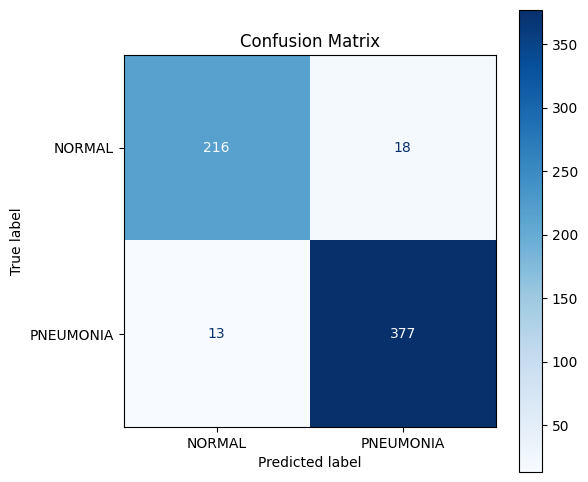

In [ ]:
cm = confusion_matrix(y_true, y_pred)
labels = valid_gen.class_indices
index_to_label = {v:k for k,v in valid_gen.class_indices.items()}
label_names = [index_to_label[i] for i in range(len(index_to_label))]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix")
plt.show()


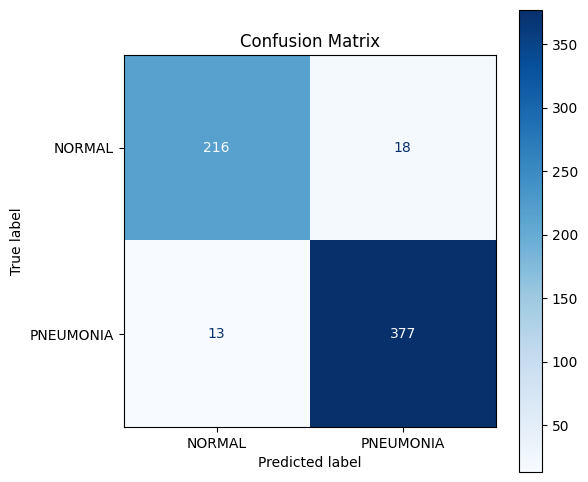

In [ ]:
cm = confusion_matrix(y_true, y_pred)
labels = valid_gen.class_indices
index_to_label = {v:k for k,v in valid_gen.class_indices.items()}
label_names = [index_to_label[i] for i in range(len(index_to_label))]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix")
plt.show()


In [ ]:
print("Classification Report (by class):")
print(classification_report(y_true, y_pred, target_names=label_names, digits=4))


Classification Report (by class):
              precision    recall  f1-score   support

      NORMAL     0.9432    0.9231    0.9330       234
   PNEUMONIA     0.9544    0.9667    0.9605       390

    accuracy                         0.9503       624
   macro avg     0.9488    0.9449    0.9468       624
weighted avg     0.9502    0.9503    0.9502       624



In [17]:
keras_file = os.path.join(OUT_DIR, f"{MODEL_NAME}.keras")
model.save(keras_file, include_optimizer=False)
print("Saved Keras-native file:", keras_file)

serving_dir = os.path.join(OUT_DIR, "exported_for_serving")
if hasattr(model, "export"):
    try:
        model.export(serving_dir)
        print("Saved serving export via model.export to:", serving_dir)
    except Exception as e:
        print("model.export failed, falling back to tf.saved_model.save:", e)
        tf.saved_model.save(model, serving_dir)
else:
    tf.saved_model.save(model, serving_dir)
    print("Saved serving via tf.saved_model.save to:", serving_dir)

meta = {
    "input_size": [IMAGE_SIZE, IMAGE_SIZE],
    "preprocessing": "resnet_preprocess",
    "class_labels": class_labels,
    "last_conv_layer": "conv5_block3_out"
}

with open(os.path.join(OUT_DIR, "meta.json"), "w") as f:
    json.dump(meta, f)
with open(os.path.join(OUT_DIR, "index_to_label.json"), "w") as f:
    json.dump(index_to_label, f)

shutil.make_archive(OUT_DIR + "_bundle", 'zip', OUT_DIR)
print("Zipped bundle to:", OUT_DIR + "_bundle.zip")

Saved Keras-native file: /content/chest_pneumonia_model/chest_pneumonia_model.keras
Saved artifact at '/content/chest_pneumonia_model/exported_for_serving'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  136378775239184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136378775239760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136378726990288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136378726991440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136378726990096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136378726991248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136378726992976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136378726994320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136378726996240: TensorSpec(shape=()